In [29]:
# Import everything
import numpy as np
import os
import imageio.v2 as imageio
import skimage
from pathlib import Path
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import regionprops, label
from ipywidgets import interact, IntSlider
from matplotlib import pyplot as plt

In [30]:
def show_as_video(video, cmap="viridis"):
    def f(i):
        plt.imshow(video[i], cmap=cmap)

    interact(f, i=IntSlider(min=0, max=len(video)-1, step=1, value=0))

In [31]:
# 1. Load the frames, convert each one to grayscale, and store them in a NumPy array of shape (N,height,width). Show the frames as a video (use the show_video function from Lab 1.1).
FRAMES_DIR = Path('./frames/')

# Load all of the individual frames as grayscale.
files = sorted(FRAMES_DIR.glob('*.jpg'))
gray_frames = [rgb2gray(imageio.imread(fp)) for fp in files]

# Stack all of them together so the first axis represents the frame number
gray_video = np.stack(gray_frames, axis=0)

print(gray_video.shape)

show_as_video(gray_video, 'gray')

(50, 240, 320)


interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

In [32]:
color_frames = [imageio.imread(fp) for fp in files]

# Stack all of them together so the first axis represents the frame number
color_video = np.stack(color_frames, axis=0)

show_as_video(color_video)

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

In [33]:
# Get the shape of the video/frames
height, width = gray_frames[0].shape
print(f'height: {height}, width: {width}')

height: 240, width: 320


In [34]:
# 2. Compute the per-pixel average of the video. Use np.mean() instead of a for loop to compute the average.
background_image = np.mean(gray_video, axis=0)
print(background_image.shape)

(240, 320)


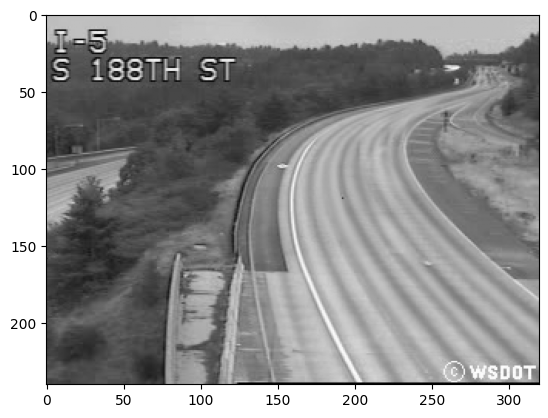

In [35]:
# 3. Show the average image, what we will call the "background" image.
plt.imshow(background_image, cmap='gray')

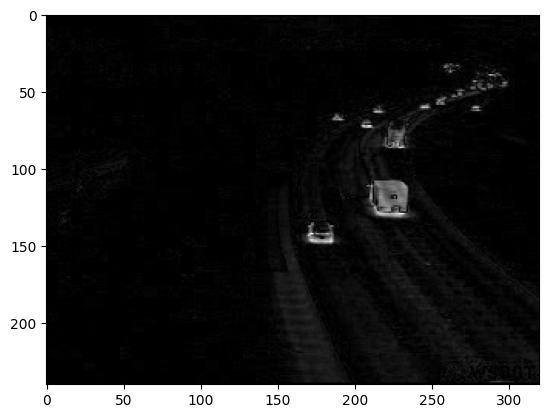

In [36]:
# 4. Compute the absolute difference between the background image and the first frame of the video and show the result.
difference_frame_1 = abs(background_image - gray_video[0])
plt.imshow(difference_frame_1, cmap='gray')

In [37]:
# 5. Use Otsu's method to determine a good threshold for the absolute difference image.
thresh_frame_1 = threshold_otsu(difference_frame_1)

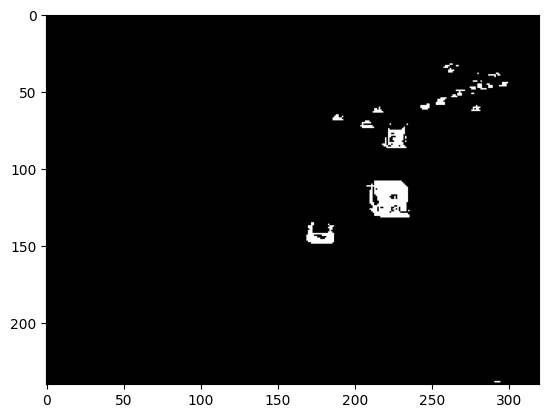

In [38]:
# 6. Threshold the absolute difference image to obtain a binary mask corresponding to the foreground pixels. Show the mask.
binary_mask_frame_1 = difference_frame_1 > thresh_frame_1
plt.imshow(binary_mask_frame_1, cmap='gray')

In [39]:
# 7. Now run the thresholding technique on each frame of the video and show the result as a video.
binary_mask_frames = []
for frame in gray_video:
    difference = abs(background_image - frame)
    thresh = threshold_otsu(difference)
    binary_mask = difference > thresh
    binary_mask_frames.append(binary_mask)

binary_mask_video = np.array(binary_mask_frames)
print(binary_mask_video.shape)

show_as_video(binary_mask_video, 'gray')

(50, 240, 320)


interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

In [40]:
# 8. Each connected blob in the binary mask is a car. Put a bounding box around each car and show the result as a video.
color = (255, 0, 0)

for binary_frame, color_frame in zip(binary_mask_video, color_video):
    labels = skimage.measure.label(binary_frame)
    regions = skimage.measure.regionprops(labels)
    for props in regions:
        ymin, xmin, ymax, xmax = props.bbox

        # Make sure we are within the bounds of the image
        ymin = max(0, ymin)
        xmin = max(0, xmin)
        ymax = min(height-1, ymax)
        xmax = min(width-1, xmax)

        # 1. Top border
        color_frame[ymin, xmin:xmax+1] = color
        # 2. Bottom border
        color_frame[ymax, xmin:xmax+1] = color
        # 3. Left border
        color_frame[ymin:ymax+1, xmin] = color
        # 4. Right border
        color_frame[ymin:ymax+1, xmax] = color

show_as_video(color_video)


interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…